In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from matplotlib import pyplot as plt
from plotly.subplots import make_subplots
import plotly.express as px
import plotly.graph_objs as go
import seaborn as sns
import missingno as msno
%matplotlib inline

# warnings
import warnings
warnings.filterwarnings('ignore',category=FutureWarning)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
rental_bike = pd.read_csv('/content/Book1 .csv')

In [ ]:
rental_bike

,HOURS,AVAILABILITY,FOOTFALL,SEASON,YEAR,WORKING DAY,HOLIDAY,TEMPRATURE,ATEMP,HUMIDITY,POLLUTION LEVEL
0,5,12,33296,1,2022,1,0,20.12,20.135,72,310
1,3,9,8346,2,2021,1,0,34.50,35.126,65,230
2,6,8,2118,4,2022,1,0,33.50,35.125,70,150
3,13,8,8256,2,2022,0,0,35.60,34.230,63,225
4,3,10,5926,4,2021,1,0,34.65,36.230,55,150
5,15,11,24447,3,2021,0,0,40.10,41.200,80,180
6,18,16,17076,4,2021,1,0,35.62,36.700,48,120
7,7,10,6026,3,2022,0,0,39.30,40.230,60,200
8,4,5,38325,2,2022,1,1,35.10,35.450,75,140
9,21,8,10256,3,2022,0,1,40.20,41.590,66,180


YEAR: year 2021 or 2022

HOURS: hour of the day (0 to 23)

SEASON: 1 = winter, 2 = spring, 3 = summer, 4 = autumn

HOLIDAY: if the day was a holiday

WORKING DAY: if the day was a working day (neither a holiday nor a weekend)

TEMPRATURE: temperature in degrees Celsius

ATEMP: sensation of temperature in degrees Celsius

HUMIDITY: relative humidity

AVAILABILITY: total number of rentals in that band

POLLUTION LEVEL: monthly avg of pollution levels

FOOTFALL: ridership per day

In [ ]:
rental_bike.head()

,HOURS,AVAILABILITY,FOOTFALL,SEASON,YEAR,WORKING DAY,HOLIDAY,TEMPRATURE,ATEMP,HUMIDITY,POLLUTION LEVEL
0,5,12,33296,1,2022,1,0,20.12,20.135,72,310
1,3,9,8346,2,2021,1,0,34.50,35.126,65,230
2,6,8,2118,4,2022,1,0,33.50,35.125,70,150
3,13,8,8256,2,2022,0,0,35.60,34.230,63,225
4,3,10,5926,4,2021,1,0,34.65,36.230,55,150


In [ ]:
rental_bike.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42 entries, 0 to 41
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   HOURS            42 non-null     int64  
 1   AVAILABILITY     42 non-null     int64  
 2   FOOTFALL         42 non-null     int64  
 3   SEASON           42 non-null     int64  
 4   YEAR             42 non-null     int64  
 5   WORKING DAY      42 non-null     int64  
 6   HOLIDAY          42 non-null     int64  
 7   TEMPRATURE       42 non-null     float64
 8   ATEMP            42 non-null     float64
 9   HUMIDITY         42 non-null     int64  
 10  POLLUTION LEVEL  42 non-null     int64  
dtypes: float64(2), int64(9)
memory usage: 3.7 KB


In [ ]:
rental_bike.shape

(42, 11)

In [ ]:
rental_bike.describe()

,HOURS,AVAILABILITY,FOOTFALL,SEASON,YEAR,WORKING DAY,HOLIDAY,TEMPRATURE,ATEMP,HUMIDITY,POLLUTION LEVEL
count,42.000000,42.000000,42.000000,42.000000,42.000000,42.000000,42.000000,42.000000,42.000000,42.000000,42.000000
mean,11.976190,17.357143,21921.904762,2.642857,2021.476190,0.690476,0.071429,32.111429,32.787500,60.333333,233.595238
std,5.421223,6.487592,44873.297110,1.122311,0.505487,0.467901,0.260661,8.219352,8.088879,13.666171,85.223396
min,0.000000,5.000000,2118.000000,1.000000,2021.000000,0.000000,0.000000,17.320000,18.256000,26.000000,50.000000
25%,9.250000,11.250000,6083.500000,2.000000,2021.000000,0.000000,0.000000,29.290000,30.450000,54.000000,155.250000
50%,12.000000,20.000000,10256.000000,3.000000,2021.000000,1.000000,0.000000,33.925000,34.193000,60.500000,248.000000
75%,16.000000,22.000000,15971.000000,4.000000,2022.000000,1.000000,0.000000,38.550000,39.325000,66.000000,307.500000
max,21.000000,30.000000,254000.000000,4.000000,2022.000000,1.000000,1.000000,45.200000,45.560000,85.000000,366.000000


In [ ]:
rental_bike.isnull().sum()

HOURS              0
AVAILABILITY       0
FOOTFALL           0
SEASON             0
YEAR               0
WORKING DAY        0
HOLIDAY            0
TEMPRATURE         0
ATEMP              0
HUMIDITY           0
POLLUTION LEVEL    0
dtype: int64

In [ ]:
rental_bike.corr()

,HOURS,AVAILABILITY,FOOTFALL,SEASON,YEAR,WORKING DAY,HOLIDAY,TEMPRATURE,ATEMP,HUMIDITY,POLLUTION LEVEL
HOURS,1.000000,0.509957,0.193338,-0.033501,-0.120367,-0.051053,0.156573,-0.213052,-0.226212,0.149571,-0.007518
AVAILABILITY,0.509957,1.000000,0.215054,-0.002153,-0.328309,0.254246,-0.390452,-0.408142,-0.388228,-0.040439,0.107949
FOOTFALL,0.193338,0.215054,1.000000,0.050259,0.260585,0.149654,-0.030398,0.011154,0.008029,0.040251,-0.136790
SEASON,-0.033501,-0.002153,0.050259,1.000000,0.135119,-0.169196,-0.077418,0.323209,0.328880,-0.069969,-0.298371
YEAR,-0.120367,-0.328309,0.260585,0.135119,1.000000,-0.186602,0.105777,0.129392,0.098567,-0.125928,-0.036747
WORKING DAY,-0.051053,0.254246,0.149654,-0.169196,-0.186602,1.000000,-0.014284,-0.282671,-0.260577,-0.094086,0.080578
HOLIDAY,0.156573,-0.390452,-0.030398,-0.077418,0.105777,-0.014284,1.000000,-0.012344,-0.025478,0.212253,-0.088698
TEMPRATURE,-0.213052,-0.408142,0.011154,0.323209,0.129392,-0.282671,-0.012344,1.000000,0.991980,-0.267663,-0.304949
ATEMP,-0.226212,-0.388228,0.008029,0.328880,0.098567,-0.260577,-0.025478,0.991980,1.000000,-0.265273,-0.343761
HUMIDITY,0.149571,-0.040439,0.040251,-0.069969,-0.125928,-0.094086,0.212253,-0.267663,-0.265273,1.000000,-0.208921


In [ ]:
rental_bike.duplicated().sum()


0

In [ ]:
rental_bike.columns

Index(['HOURS ', 'AVAILABILITY', 'FOOTFALL ', 'SEASON', 'YEAR', 'WORKING DAY',
       'HOLIDAY ', 'TEMPRATURE ', 'ATEMP', 'HUMIDITY', 'POLLUTION LEVEL'],
      dtype='object')

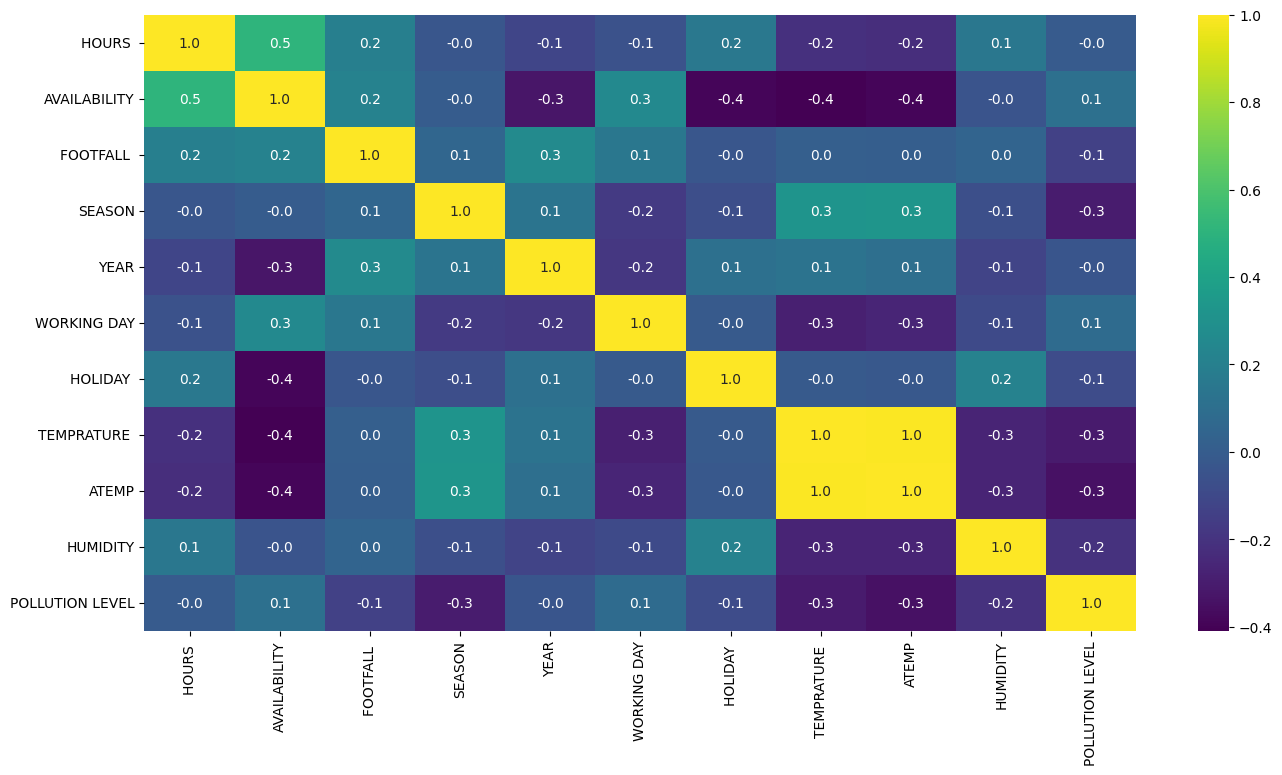

In [ ]:
plt.figure(figsize= (16, 8))
sns.heatmap(rental_bike.corr(), annot = True, cmap= 'viridis', fmt= '.1f');

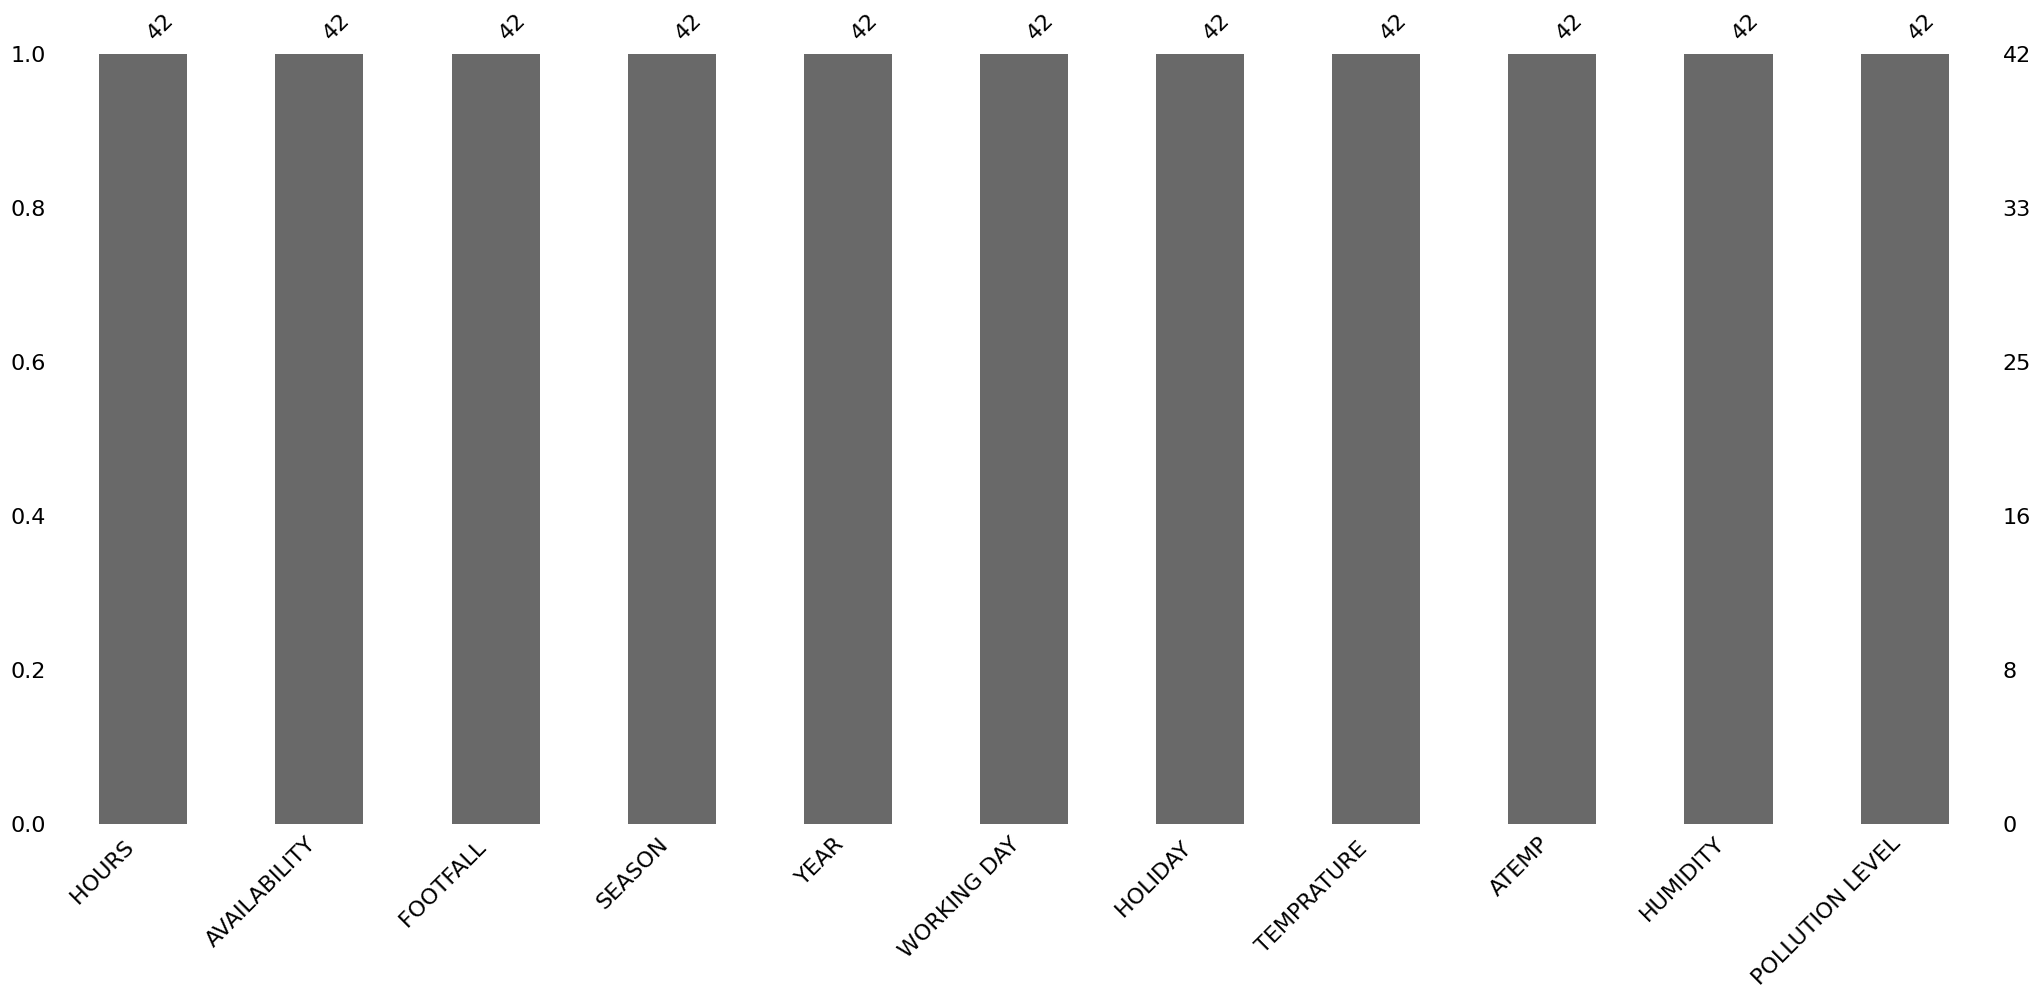

In [ ]:
msno.bar(rental_bike);

In [ ]:
rental_bike['SEASON'] = rental_bike['SEASON'].map({1:'winter',2:'spring',3:'summer',4:'autumn'})

In [ ]:
px.histogram(rental_bike,x='SEASON',y='AVAILABILITY',template='ggplot2',color='SEASON',color_discrete_sequence = px.colors.sequential.RdBu)

In [ ]:
px.sunburst(rental_bike,path=['SEASON'],values='AVAILABILITY',template='ggplot2',color='SEASON')

In [ ]:
px.sunburst(rental_bike,path=['YEAR'],values='AVAILABILITY')

In [ ]:
fig = px.histogram(rental_bike,x='WORKING DAY',y='AVAILABILITY',template='ggplot2',color='WORKING DAY',color_discrete_sequence = px.colors.sequential.RdBu)
fig.update_layout(bargap=0.2)
fig.show()

In [ ]:
fig = px.sunburst(rental_bike, path=['WORKING DAY'], values='AVAILABILITY',template='ggplot2',title='Working Day Rental Rate')
fig.show()

In [ ]:
fig = px.sunburst(rental_bike, path=['SEASON', 'HUMIDITY'], values='AVAILABILITY')
fig.show()

<Figure size 1500x700 with 0 Axes>

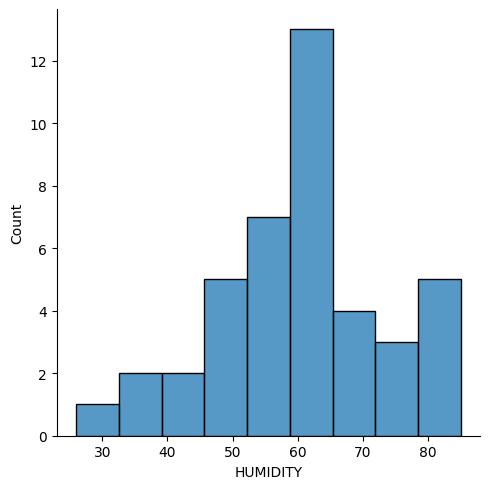

In [ ]:
plt.figure(figsize=(15,7))
sns.displot(rental_bike['HUMIDITY']);

<Figure size 1500x700 with 0 Axes>

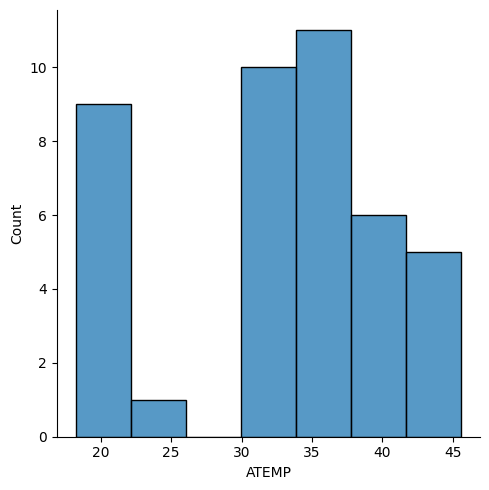

In [ ]:
plt.figure(figsize=(15,7))
sns.displot(rental_bike['ATEMP']);

In [ ]:
fig = px.bar(rental_bike, x="ATEMP", y="YEAR", color='SEASON', orientation='h',
             hover_data=["ATEMP", "HUMIDITY"],
             height=400,
             title='temperature and humidity in seasons by year')
fig.show()

<Figure size 1500x1000 with 0 Axes>

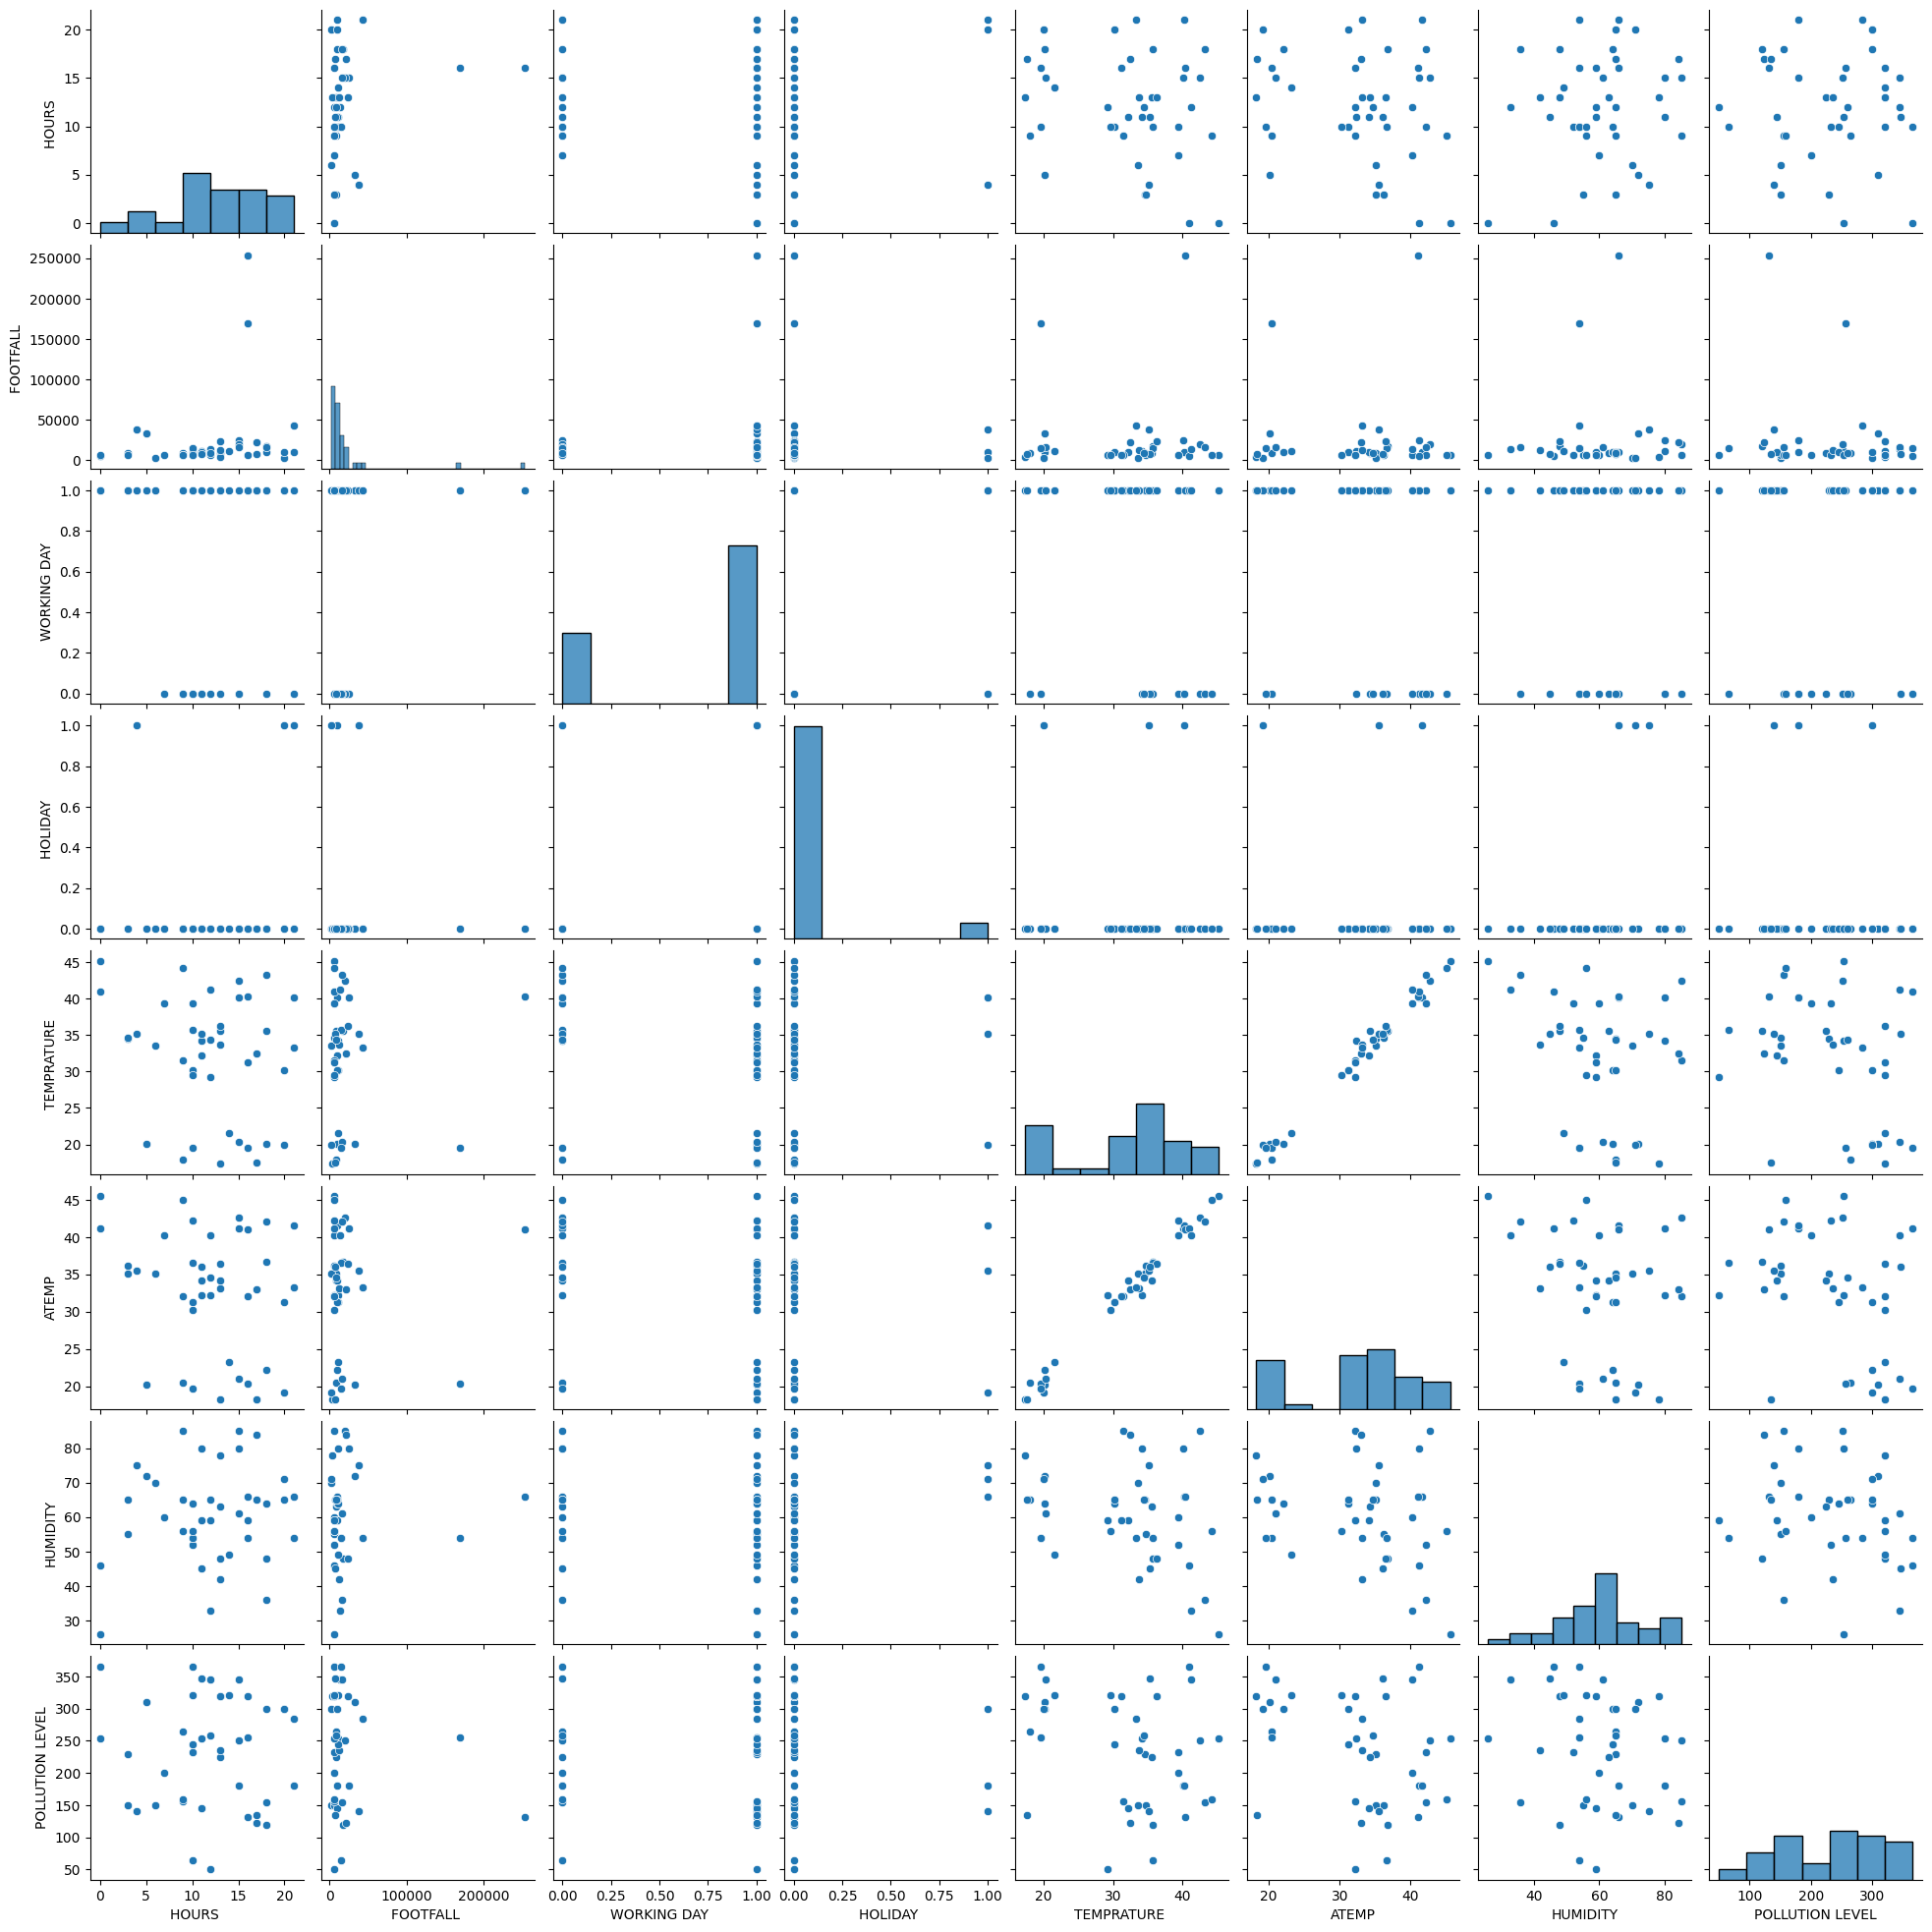

In [ ]:
plt.figure(figsize=(15,10))
sns.pairplot(rental_bike.drop(['AVAILABILITY','YEAR'],axis=1))

In [ ]:
for col in rental_bike.columns:

    print(f"{col:15} ----> {rental_bike[col].nunique():7}  unique values")

HOURS           ---->      18  unique values
AVAILABILITY    ---->      19  unique values
FOOTFALL        ---->      39  unique values
SEASON          ---->       4  unique values
YEAR            ---->       2  unique values
WORKING DAY     ---->       2  unique values
HOLIDAY         ---->       2  unique values
TEMPRATURE      ---->      40  unique values
ATEMP           ---->      42  unique values
HUMIDITY        ---->      27  unique values
POLLUTION LEVEL ---->      33  unique values


In [ ]:
!pip install --upgrade scikit-learn
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.3/13.3 MB 53.1 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.2.2
    Uninstalling scikit-learn-1.2.2:
      Successfully uninstalled scikit-learn-1.2.2


In [ ]:
rental_bike = pd.read_csv('/content/Book1 .csv')

In [ ]:
X = rental_bike.drop('SEASON', axis=1)
y = rental_bike['SEASON']


In [ ]:
# Split the data into training and testing sets (adjust test_size as needed)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# If you need a validation set, split the training set further
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=42)

# Now you have training, validation, and testing sets
print("Training set size:", X_train.shape)
print("Validation set size:", X_val.shape)
print("Testing set size:", X_test.shape)

Training set size: (23, 10)
Validation set size: (8, 10)
Testing set size: (11, 10)


In [ ]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)


In [ ]:
rf.fit(X_train, y_train)


RandomForestRegressor(random_state=42)

In [ ]:
y_pred = rf.predict(X_test)

In [ ]:
importances = rf.feature_importances_
feature_importance = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

print(feature_importance)

           Feature  Importance
9  POLLUTION LEVEL    0.401130
2        FOOTFALL     0.126902
1     AVAILABILITY    0.115954
8         HUMIDITY    0.109303
7            ATEMP    0.079157
0           HOURS     0.071242
6      TEMPRATURE     0.050154
4      WORKING DAY    0.034096
3             YEAR    0.011429
5         HOLIDAY     0.000633


In [ ]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'Mean Squared Error: {mse}')
print(f"R-squared Score: {r2:.2f}")

Mean Squared Error: 1.2151272727272728
R-squared Score: 0.02


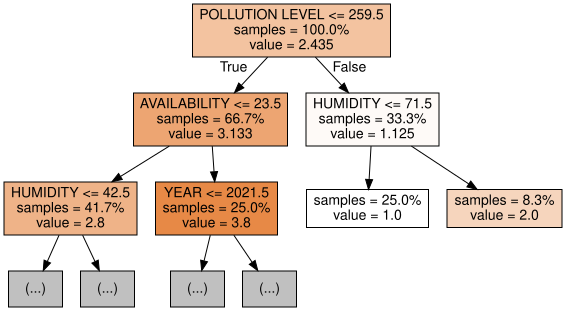

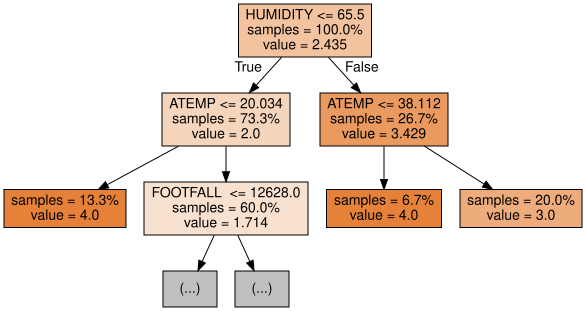

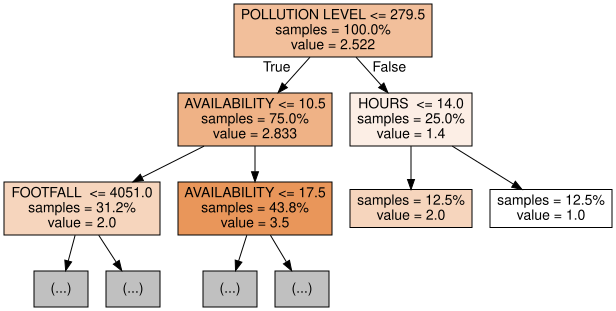

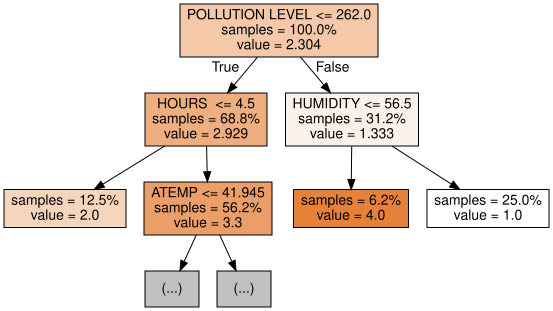

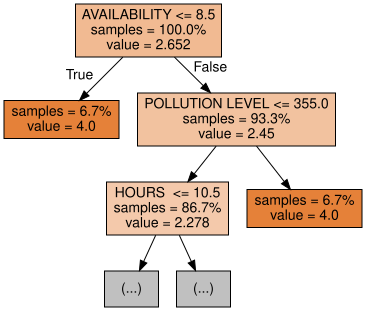

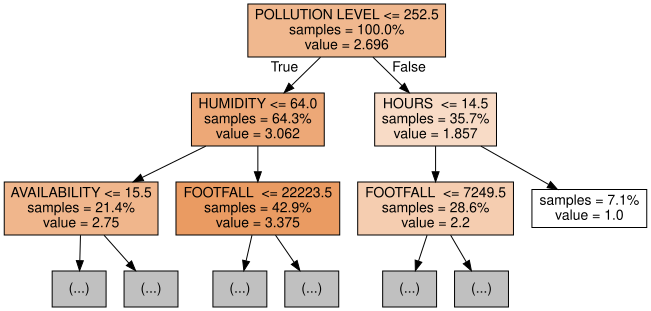

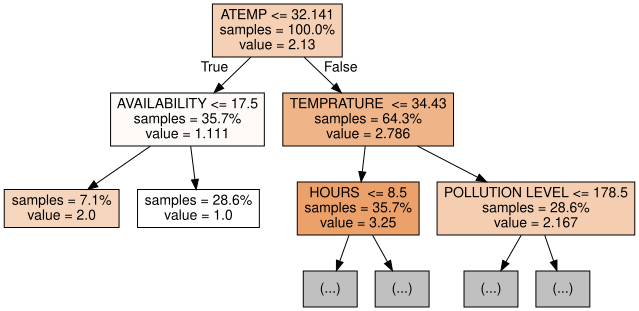

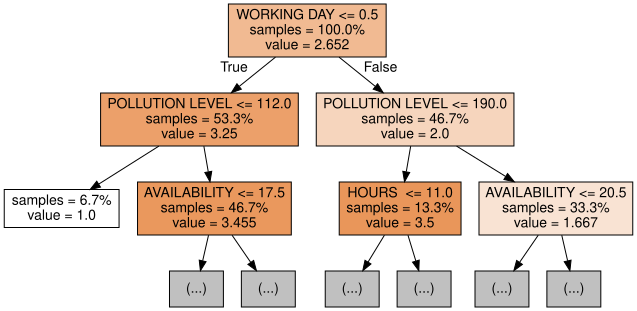

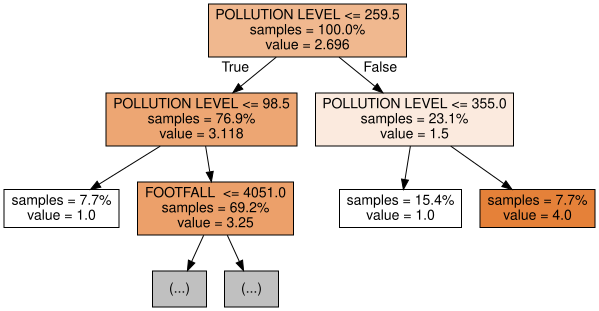

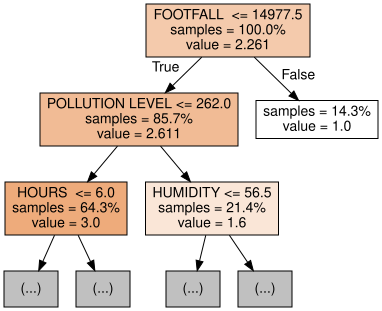

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.tree import export_graphviz # Import export_graphviz
import graphviz

# ... (rest of your code)

# Export the first three decision trees from the forest
for i in range(10):
    tree = rf.estimators_[i]
    dot_rental_bike = export_graphviz(tree,
                               feature_names=X_train.columns,
                               filled=True,
                               max_depth=2,
                               impurity=False,
                               proportion=True)
    graph = graphviz.Source(dot_rental_bike)
    display(graph)

In [ ]:
# instantiate the classifier

rfc = RandomForestClassifier(random_state=42)



# fit the model
# Include the option include_lowest=True to capture values at the edge of the first bin
y_train_cat = pd.cut(y_train, bins=[0, 10, 20, 30], labels=[0, 1, 2], include_lowest=True)

# Handle potential NaNs (if any remain after including the lowest value)
y_train_cat = y_train_cat.cat.add_categories(-1).fillna(-1) # Replace NaN with a new category

rfc.fit(X_train, y_train_cat)



# Predict the Test set results
y_pred = rfc.predict(X_test)

# Discretize y_test to match y_pred
y_test_cat = pd.cut(y_test, bins=[0, 10, 20, 30], labels=[0, 1, 2], include_lowest=True)
y_test_cat = y_test_cat.cat.add_categories(-1).fillna(-1) # Handle NaNs if any

# Check accuracy score
print('Model accuracy score with 10 decision-trees : {0:0.4f}'. format(accuracy_score(y_test_cat, y_pred))) # Compare discretized y_test

Model accuracy score with 10 decision-trees : 1.0000


In [ ]:
!pip install --upgrade scikit-learn
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
rental_bike = pd.read_csv('/content/Book1 .csv')
print(rental_bike.tail())

    HOURS   AVAILABILITY  FOOTFALL   SEASON  YEAR  WORKING DAY  HOLIDAY   \
37      10            20      14955       4  2022            0         0   
38      10            15       5984       2  2022            1         0   
39      11            15       7549       3  2022            0         0   
40       9            20       6256       4  2021            0         0   
41      12            13       8515       3  2021            0         0   

    TEMPRATURE    ATEMP  HUMIDITY  POLLUTION LEVEL  
37        19.50  19.609        54              365  
38        29.56  30.190        56              321  
39        35.20  36.043        45              347  
40        44.20  45.020        56              159  
41        34.36  34.609        65              259  


In [ ]:
X = rental_bike.drop('SEASON', axis=1)
y = rental_bike['SEASON']

In [ ]:
# Split the data into training and testing sets (adjust test_size as needed)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# If you need a validation set, split the training set further
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=42)

# Now you have training, validation, and testing sets
print("Training set size:", X_train.shape)
print("Validation set size:", X_val.shape)
print("Testing set size:", X_test.shape)

Training set size: (23, 10)
Validation set size: (8, 10)
Testing set size: (11, 10)


In [ ]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)

In [ ]:
rf.fit(X_train, y_train)


RandomForestRegressor(random_state=42)

In [ ]:
y_pred = rf.predict(X_test)

In [ ]:
importances = rf.feature_importances_
feature_importance = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

print(feature_importance)

           Feature  Importance
9  POLLUTION LEVEL    0.401130
2        FOOTFALL     0.126902
1     AVAILABILITY    0.115954
8         HUMIDITY    0.109303
7            ATEMP    0.079157
0           HOURS     0.071242
6      TEMPRATURE     0.050154
4      WORKING DAY    0.034096
3             YEAR    0.011429
5         HOLIDAY     0.000633


In [ ]:
!pip install dash

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 13.0 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import dash
import dash_core_components as dcc
import dash_html_components as html
from dash.dependencies import Input, Output

<ipython-input-51-1ac9e5149c18>:6: UserWarning:


The dash_core_components package is deprecated. Please replace
`import dash_core_components as dcc` with `from dash import dcc`

<ipython-input-51-1ac9e5149c18>:7: UserWarning:


The dash_html_components package is deprecated. Please replace
`import dash_html_components as html` with `from dash import html`



In [ ]:
fig1 = px.bar(
    rental_bike,
    x=rental_bike.groupby("SEASON")["AVAILABILITY"].agg(sum),
    y=rental_bike["SEASON"].unique(),
    labels={"x": "SEASON", "y": "AVAILABILITY"},
    color=rental_bike.groupby("SEASON")["AVAILABILITY"].agg(sum),
    color_continuous_scale=px.colors.sequential.RdBu,
    text=rental_bike.groupby("SEASON")["AVAILABILITY"].agg(sum),
    title="Availability of rental bikes on diffrent seasons",
    orientation="h"
)
fig1.update_layout(
    title=dict(x=0.5),
    margin=dict(l=550, r=20, t=60, b=20),
    paper_bgcolor="#D6EAF8",
)
fig1.update_traces(texttemplate="%{text:.2s}")

In [ ]:
fig2 = px.scatter(
    rental_bike, #dataframe
    x="WORKING DAY", #x
    y="POLLUTION LEVEL", #y
    size="AVAILABILITY", #bubble size
    color="AVAILABILITY",#bubble color
    color_continuous_scale=px.colors.sequential.Plotly3, #color theme
    title="Availability of rental bike with respect to pollution level and working day ", #chart title
)
fig2.update_layout(
    xaxis_tickangle=30,#angle of the tick on x-axis
    title=dict(x=0.5), #set the title in center
    xaxis_tickfont=dict(size=9), #set the font for x-axis
    yaxis_tickfont=dict(size=9), #set the font for y-axis
    margin=dict(l=500, r=20, t=50, b=20), #set the margin
    paper_bgcolor="LightSteelblue", #set the background color for chart
)

In [ ]:
fig4= px.bar(rental_bike,
             x = rental_bike.groupby('HUMIDITY')['AVAILABILITY'].agg(sum),
             y = rental_bike['HUMIDITY'].unique(),
             labels={
                     "x": "HUMIDITY",
                     "y": "AVAILABILITY"
                 },
              color = rental_bike.groupby('HUMIDITY')['AVAILABILITY'].agg(sum),
              color_continuous_scale=px.colors.sequential.Sunset,
              #color_discrete_sequence=['rgb(253,180,98)','rgb(190,186,218)'],
              text = rental_bike.groupby('HUMIDITY')['AVAILABILITY'].agg(sum),
             title = 'Availability of rental bikes with respect to humidity levels',
              #,barmode = 'group'
              orientation = 'h'
             )
fig4.update_layout( title = dict(x=0.5), paper_bgcolor="#BDBDBD")
fig4.update_traces(texttemplate = '%{text:.2s}')

In [ ]:
app = dash.Dash(__name__)
app.layout = html.Div(
    children=[
        html.Div(
            children=[
                html.P(children="🚲", style={'fontSize': "30px",'textAlign': 'center'}, className="header-emoji"), #emoji
                html.H1(
                    children="Rental bike analytics",style={'textAlign': 'center'}, className="header-title"
                ), #Header title
                html.H2(
                    children="Analyzing the rental bike availability by variable factors for the year 2021 to 2022",
                    className="header-description", style={'textAlign': 'center'},
                ),
            ],
            className="header",style={'backgroundColor':'#F5F5F5'},
        ), #Description below the header


        html.Div(
            children=[
                html.Div(children = 'YEAR', style={'fontSize': "24px"},className = 'menu-title'),
                dcc.Dropdown(
                    id = 'Year-filter',
                    options = [
                        {'label': YEAR, 'value':YEAR}
                        for YEAR in rental_bike.YEAR.unique()
                    ], #'YEAR' is the filter
                    value ='2021',
                    clearable = False,
                    searchable = False,
                    className = 'dropdown', style={'fontSize': "24px",'textAlign': 'center'},
                ),
            ],
            className = 'menu',
        ), #the dropdown function

        html.Div(
            children=[
                html.Div(
                children = dcc.Graph(
                    id = 'scatter',
                    figure = fig2,
                  #  config={"displayModeBar": False},
                ),
                style={'width': '50%', 'display': 'inline-block'},
            ),
                html.Div(
                children = dcc.Graph(
                    id = 'bar',
                    figure = fig1,
                    #config={"displayModeBar": False},
                ),
                style={'width': '50%', 'display': 'inline-block'},
            ),
                html.Div(
                children = dcc.Graph(
                    id = 'barscene',
                    figure = fig4,
                    #config={"displayModeBar": False},
                ),
                style={'width': '50%', 'display': 'inline-block'},
            ),
        ],
        className = 'double-graph',
        ),
    ]
)

In [ ]:
@app.callback(
    Output("scatter", "figure"), #the output is the scatterchart
    [Input("year-filter", "value")], #the input is the year-filter
)
def update_charts(Year):
    filtered_data = rental_bike[rental_bike["YEAR"] == Year] #the graph/dataframe will be filterd by "YEAR"
    # Correct the indentation of this line:
    scatter = px.scatter(
        filtered_data,
        x="WORKING DAY",
        y="POLLUTION LEVEL",
        size="AVAILABILITY",
        color="AVAIBILITY",
        color_continuous_scale=px.colors.sequential.Plotly3,
        title="Availability of rental bike with respect to pollution level and working day ",
    )
    scatter.update_layout(
        xaxis_tickangle=30,
        title=dict(x=0.5),
        xaxis_tickfont=dict(size=9),
        yaxis_tickfont=dict(size=9),
        margin=dict(l=500, r=20, t=50, b=20),
        paper_bgcolor="LightSteelblue",
    )
    return scatter #return the scatterchart according to the filter

@app.callback(
    Output("bar", "figure"),
    [Input("YEAR-filter", "value")],
)
def update_charts(YEAR):
    filtered_data = rental_bike[rental_bike["YEAR"] == YEAR]
    bar = px.bar(
        filtered_data,
        x=filtered_data.groupby("SEASON")["AVAILABILITY"].agg(sum),
        y=filtered_data["SEASON"].unique(),
        color=filtered_data.groupby("SEASON")["AAVAILABILTY"].agg(sum),
        color_continuous_scale=px.colors.sequential.RdBu,
        text=filtered_data.groupby("SEASON")["AVAILABILITY"].agg(sum),
        title="Availability of rental bikes on diffrent seasons",
        orientation="h",
    )
    bar.update_layout(
        title=dict(x=0.5), margin=dict(l=550, r=20, t=60, b=20), paper_bgcolor="#D6EAF8"
    )
    bar.update_traces(texttemplate="%{text:.2s}")
    return bar
@app.callback(
    Output("bibar", "figure"),
    [Input("YEAR-filter", "value")],
)
def update_charts(YEAR):
    filtered_data = rental_bike[rental_bike["YEAR"] == YEAR]
    barscene = px.bar(
        filtered_data,
        x=filtered_data.groupby("HUMIDITY")["AVAILABILITY"].agg(sum),
        y=filtered_data["AVAILABILITY"].unique(),
        labels={"x": "HUMIDITY", "y": "AVAILABILTY"},
        color=filtered_data.groupby("HUMIDITY")["AVAILABILiTY"].agg(sum),
        color_continuous_scale=px.colors.sequential.Sunset,
        # color_discrete_sequence=['rgb(253,180,98)','rgb(190,186,218)'],
        text=filtered_data.groupby("HUMIDITY")["AVAILABILITY"].agg(sum),
        title="Availability of rental bikes with respect to humidity levels",
        # ,barmode = 'group'
        orientation="h",
    )
    barscene.update_layout(title=dict(x=0.5), paper_bgcolor="#BDBDBD")
    barscene.update_traces(texttemplate="%{text:.2s}")
    return barscene

In [ ]:
##if not using virtual environment
if __name__ == '__main__':
    app.run_server()


<IPython.core.display.Javascript object>

In [ ]:
import dash
import dash_core_components as dcc
import dash_html_components as html
from dash.dependencies import Input, Output
import plotly.express as px

# Assume rental_bike is your pandas DataFrame containing the rental bike data

# Initialize your Dash app
app = dash.Dash(__name__)

# Define the layout of your web page
app.layout = html.Div([
    dcc.Dropdown(
        id='year-filter',
        options=[{'label': year, 'value': year} for year in rental_bike['YEAR'].unique()],
        value=rental_bike['YEAR'].min(),  # Set initial value to the minimum year available
        clearable=False,  # Prevents clearing of the dropdown
    ),
    dcc.Graph(id='scatter'),
    dcc.Graph(id='bar'),
    dcc.Graph(id='bibar'),
])

# Define callbacks to update graphs based on dropdown selection
@app.callback(
    Output("scatter", "figure"),
    [Input("year-filter", "value")],
)
def update_scatter(Year):
    filtered_data = rental_bike[rental_bike["YEAR"] == Year]
    scatter = px.scatter(
        filtered_data,
        x="WORKING DAY",
        y="POLLUTION LEVEL",
        size="AVAILABILITY",
        color="AVAILABILITY",  # corrected typo here
        color_continuous_scale=px.colors.sequential.Plotly3,
        title="Availability of rental bike with respect to pollution level and working day",
    )
    scatter.update_layout(
        xaxis_tickangle=30,
        title=dict(x=0.5),
        xaxis_tickfont=dict(size=9),
        yaxis_tickfont=dict(size=9),
        margin=dict(l=50, r=20, t=50, b=20),  # adjusted margin
        paper_bgcolor="LightSteelBlue",  # corrected color name
    )
    return scatter

@app.callback(
    Output("bar", "figure"),
    [Input("year-filter", "value")],
)
def update_bar(YEAR):  # corrected function name and input variable
    filtered_data = rental_bike[rental_bike["YEAR"] == YEAR]
    bar = px.bar(
        filtered_data,
        x=filtered_data.groupby("SEASON")["AVAILABILITY"].sum(),  # corrected aggregation function
        y=filtered_data["SEASON"].unique(),
        color=filtered_data.groupby("SEASON")["AVAILABILITY"].sum(),  # corrected aggregation function
        color_continuous_scale=px.colors.sequential.RdBu,
        text=filtered_data.groupby("SEASON")["AVAILABILITY"].sum(),  # corrected aggregation function
        title="Availability of rental bikes on different seasons",
        orientation="h",
    )
    bar.update_layout(
        title=dict(x=0.5),
        margin=dict(l=50, r=20, t=60, b=20),  # adjusted margin
        paper_bgcolor="#D6EAF8",
    )
    bar.update_traces(texttemplate="%{text:.2s}")
    return bar

@app.callback(
    Output("bibar", "figure"),
    [Input("year-filter", "value")],
)
def update_bibar(YEAR):  # corrected function name and input variable
    filtered_data = rental_bike[rental_bike["YEAR"] == YEAR]
    bibar = px.bar(
        filtered_data,
        x=filtered_data.groupby("HUMIDITY")["AVAILABILITY"].sum(),  # corrected aggregation function
        y=filtered_data["AVAILABILITY"].unique(),
        labels={"x": "HUMIDITY", "y": "AVAILABILITY"},  # corrected label
        color=filtered_data.groupby("HUMIDITY")["AVAILABILITY"].sum(),  # corrected aggregation function
        color_continuous_scale=px.colors.sequential.Sunset,
        text=filtered_data.groupby("HUMIDITY")["AVAILABILITY"].sum(),  # corrected aggregation function
        title="Availability of rental bikes with respect to humidity levels",
        orientation="h",
    )
    bibar.update_layout(
        title=dict(x=0.5),
        paper_bgcolor="#BDBDBD",
    )
    bibar.update_traces(texttemplate="%{text:.2s}")
    return bibar

# Run the Dash application
if __name__ == '__main__':
    app.run_server(debug=True)


<IPython.core.display.Javascript object>

In [ ]:
!pip freeze > requirements.txt
